<a href="https://colab.research.google.com/github/Mastermind0309/NTUH_HCC/blob/main/Table2BarChart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

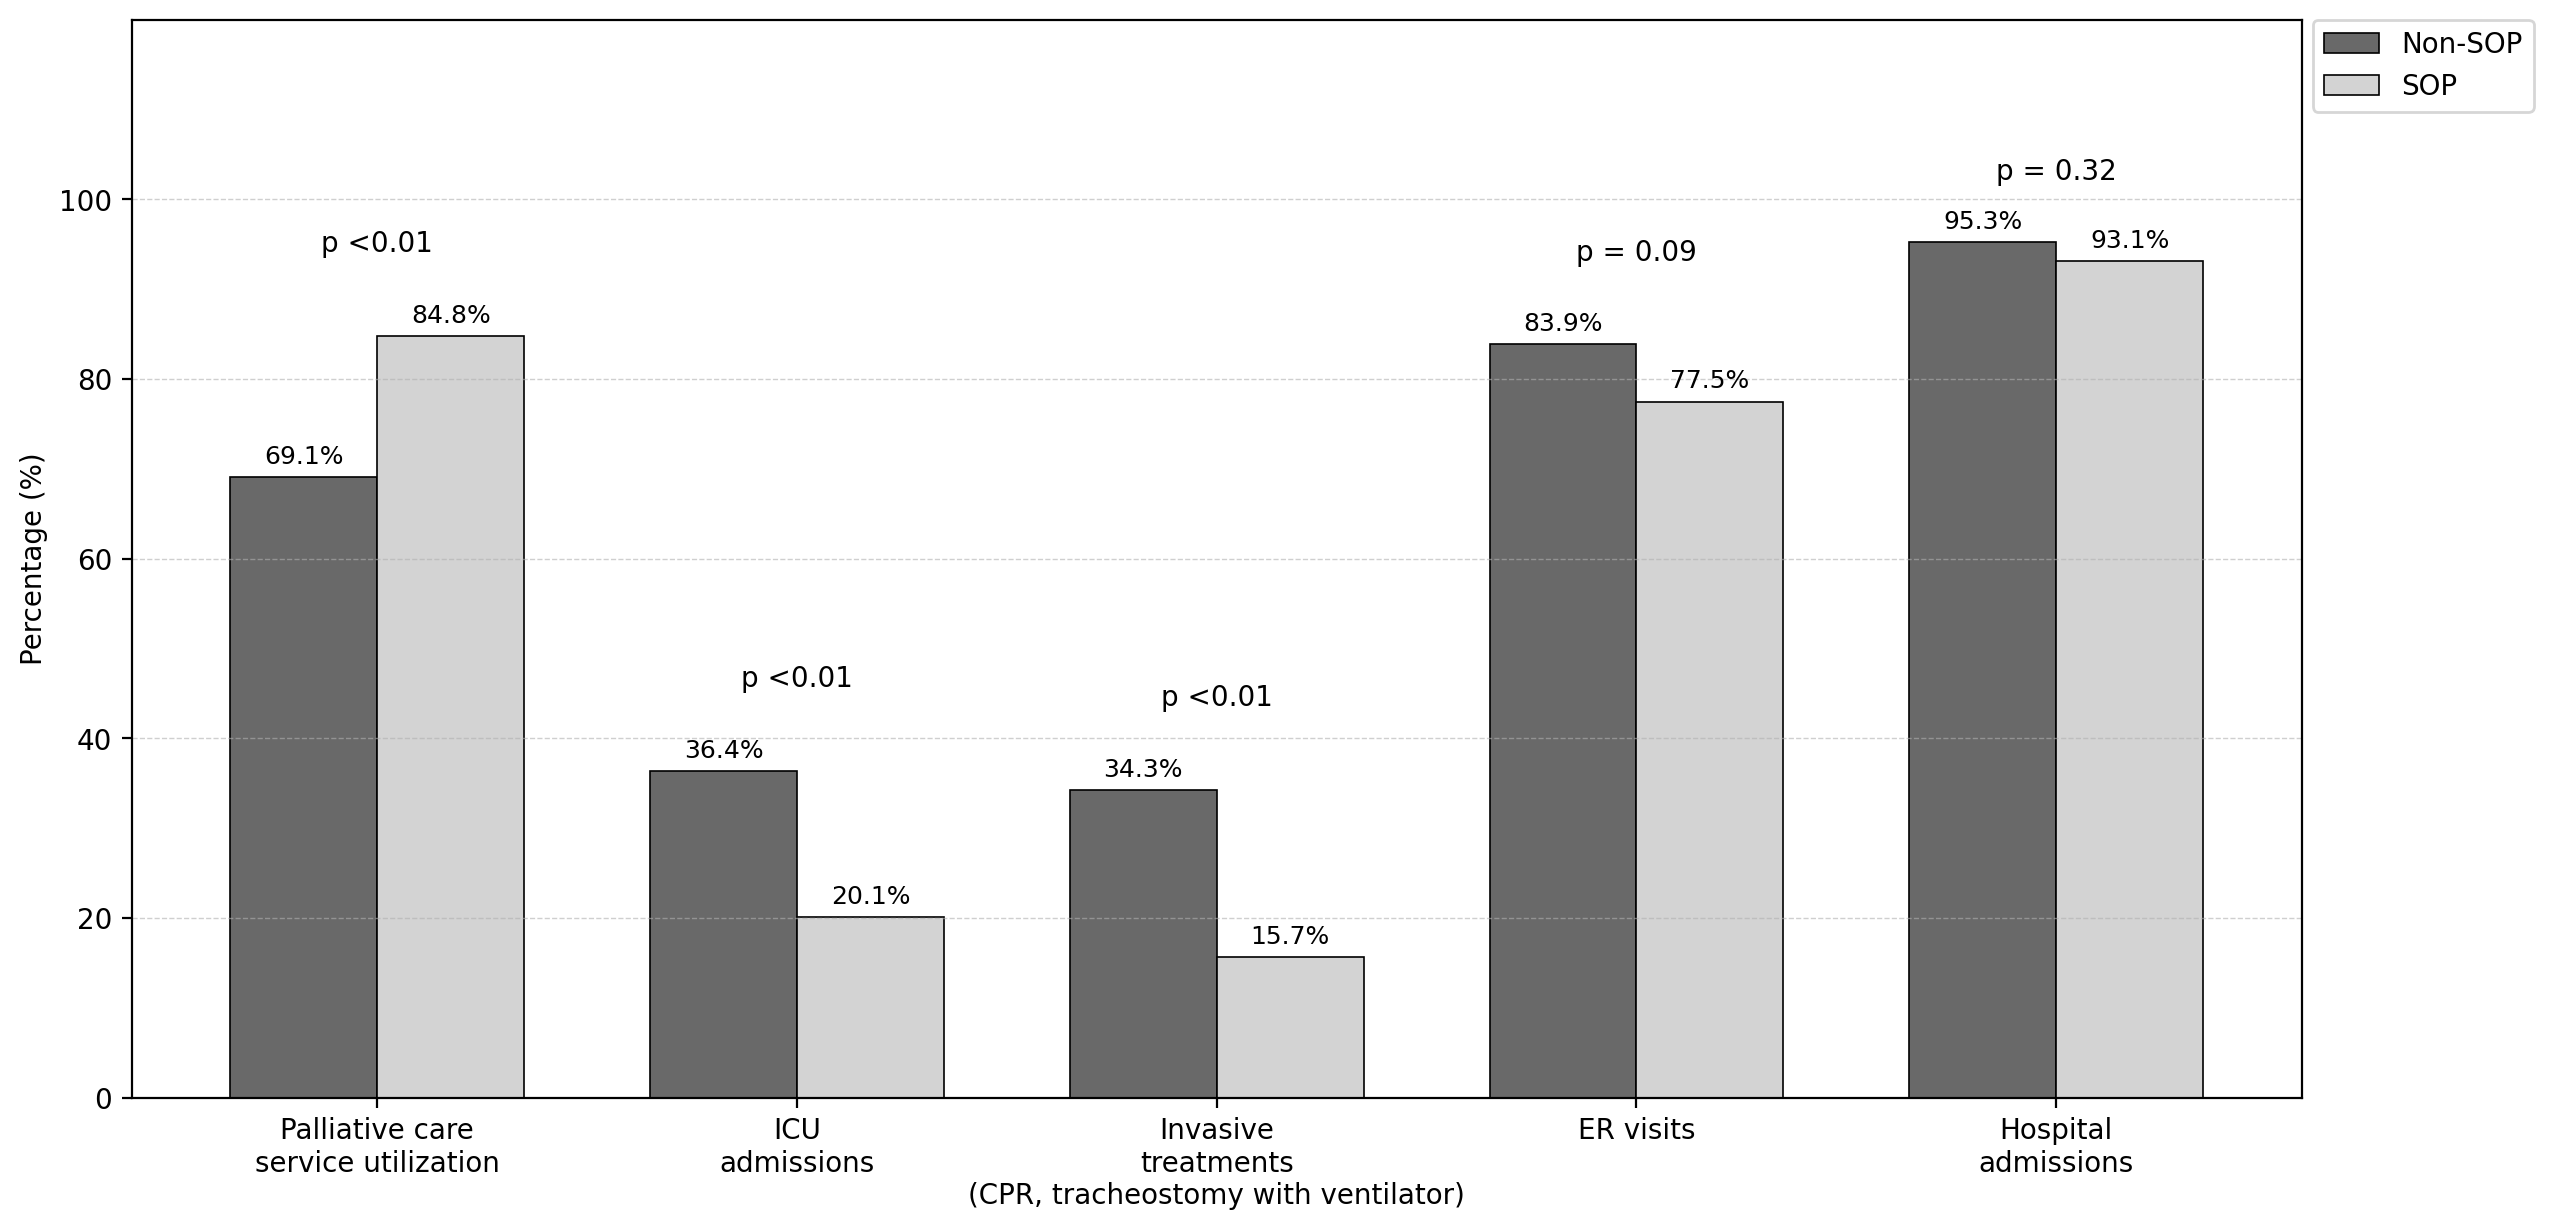

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt

# ===== Data in Table 2 order, ER before Hospital =====
categories = [
    "Palliative care\nservice utilization",
    "ICU\nadmissions",
    "Invasive\ntreatments\n(CPR, tracheostomy with ventilator)",
    "ER visits",
    "Hospital\nadmissions"
]
non_sop = [69.1, 36.4, 34.3, 83.9, 95.3]
sop     = [84.8, 20.1, 15.7, 77.5, 93.1]
pvals   = ["<0.01", "<0.01", "<0.01", "0.09", "0.32"]

non_sop_labels = [f"{v:.1f}%" for v in non_sop]
sop_labels     = [f"{v:.1f}%" for v in sop]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7), dpi=200)

# Greyscale bars
bars1 = ax.bar(x - width/2, non_sop, width, label="Non-SOP",
               color="dimgray", edgecolor="black", linewidth=0.6)
bars2 = ax.bar(x + width/2, sop,     width, label="SOP",
               color="lightgray", edgecolor="black", linewidth=0.6)

# Keep frame tall (to 120) but ticks only to 100
ax.set_ylim(0, 120)
ax.set_yticks(np.arange(0, 101, 20))  # tick marks stop at 100
ax.set_ylabel("Percentage (%)")
ax.set_xticks(x)
ax.set_xticklabels(categories)

# Title
#ax.set_title(
#   "Figure 3. Comparison of palliative care service utilization and medical resource "
#  "utilization between SOP and non-SOP groups (n = 440).",
#    pad=24
#)

# Legend outside
ax.legend(loc="upper left", bbox_to_anchor=(1.005, 1.00), borderaxespad=0.0)

# ---- annotate % on bars ----
def autolabel(bc, labels):
    for bar, label in zip(bc, labels):
        h = bar.get_height()
        ax.annotate(label,
                    xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha="center", va="bottom", fontsize=9)
autolabel(bars1, non_sop_labels)
autolabel(bars2, sop_labels)

# ---- p-values ----
for i, p in enumerate(pvals):
    pair_top = max(non_sop[i], sop[i])
    label = f"p {p}" if p.startswith("<") else f"p = {p}"  # format: p < 0.01
    if p == "0.32":  # hospital admission, special placement
        ax.annotate(label,
                    xy=(x[i], pair_top),
                    xytext=(0, 20),            # comfortably between bar and frame
                    textcoords="offset points",
                    ha="center", va="bottom", fontsize=10,
                    bbox=dict(facecolor="white", edgecolor="none", alpha=0.7))
    else:
        ax.annotate(label,
                    xy=(x[i], pair_top),
                    xytext=(0, 28),            # well above bar but inside frame
                    textcoords="offset points",
                    ha="center", va="bottom", fontsize=10)

# Gridlines
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

# Footnote
# footnote = (
#    "Abbreviations: SOP, Shared decision-making with Oncologists and Palliative care specialists; "
#   "ICU, intensive care unit; CPR, cardiopulmonary resuscitation; ER, emergency room. "
#    "P-values were calculated using chi-squared test for all variables."
#)
#plt.tight_layout(rect=[0, 0.12, 0.84, 0.86])
#fig.text(0.5, 0.04, footnote, ha="center", va="center", fontsize=9)

plt.show()

# High-DPI export
fig.savefig("table2_bar_chart_pvalues_greyscale_ticks100.png", dpi=600, bbox_inches="tight")
